In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
# load the dataset
titanic_df = sns.load_dataset('titanic')

In [3]:
titanic_df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [4]:
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
# Process the data
# Selecting features for SVD
features = ['class', 'sex', 'age', 'fare', 'survived']

# Pipeline for numerical features
numeric_features = ['age', 'fare']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# Categorical features and transformer (fix for NameError)
categorical_features = ['class', 'sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Preprocessor (use correct parameter name and keep unspecified cols like 'survived')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)],
    remainder='passthrough')

# Applying preprocessing to the dataset
X = preprocessor.fit_transform(titanic_df[features])

In [9]:
X

array([[-0.56573646, -0.50244517,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.66386103,  0.78684529,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [-0.25833709, -0.48885426,  0.        , ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [-0.1046374 , -0.17626324,  0.        , ...,  1.        ,
         0.        ,  0.        ],
       [-0.25833709, -0.04438104,  1.        , ...,  0.        ,
         1.        ,  1.        ],
       [ 0.20276197, -0.49237783,  0.        , ...,  0.        ,
         1.        ,  0.        ]], shape=(891, 8))

In [13]:
titanic_df[features].shape

(891, 5)

In [12]:
X.shape

(891, 8)

In [17]:
# perform SVD
svd = TruncatedSVD(n_components=2) # You can adjust n_components
Y = svd.fit_transform(X)
print("Singular Values:", svd.singular_values_)
print("Explained Variance Ratio:", svd.explained_variance_ratio_)

Singular Values: [34.09223472 31.42264196]
Explained Variance Ratio: [0.34659041 0.05793594]


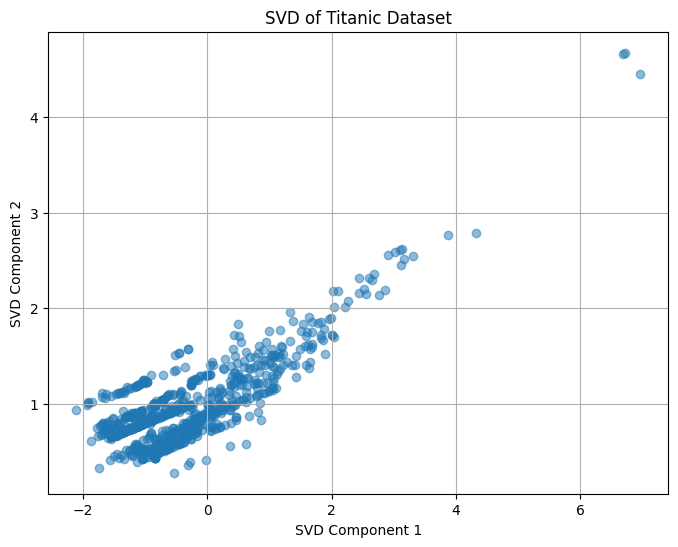

In [18]:
import matplotlib.pyplot as plt

# Assuming Y is the result from SVD with 2 components
plt.figure(figsize=(8, 6))
plt.scatter(Y[:, 0], Y[:, 1], alpha=0.5)
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('SVD of Titanic Dataset')
plt.grid(True)
plt.show()